In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("House Pricing.csv")

print(df.head())

print(df.shape)

print(df.info())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [4]:
variables = ['SalePrice', 'GrLivArea', '2ndFlrSF']

datos = df[variables]

In [5]:
print(datos.mean())

SalePrice    180921.195890
GrLivArea      1515.463699
2ndFlrSF        346.992466
dtype: float64


In [6]:
print(datos.std())

SalePrice    79442.502883
GrLivArea      525.480383
2ndFlrSF       436.528436
dtype: float64


In [7]:
print(datos.var())

SalePrice    6.311111e+09
GrLivArea    2.761296e+05
2ndFlrSF     1.905571e+05
dtype: float64


In [8]:
print(datos.describe())

           SalePrice    GrLivArea     2ndFlrSF
count    1460.000000  1460.000000  1460.000000
mean   180921.195890  1515.463699   346.992466
std     79442.502883   525.480383   436.528436
min     34900.000000   334.000000     0.000000
25%    129975.000000  1129.500000     0.000000
50%    163000.000000  1464.000000     0.000000
75%    214000.000000  1776.750000   728.000000
max    755000.000000  5642.000000  2065.000000


In [10]:
for col in variables:

    stat, p = shapiro(datos[col].dropna())

    print(f"\nVariable: {col}")
    print(f"Estadístico = {stat:.4f}")
    print(f"p-value = {p:.4f}")

    if p > 0.05:
        print("Distribución Normal")
    else:
        print("No distribución normal")


Variable: SalePrice
Estadístico = 0.8697
p-value = 0.0000
No distribución normal

Variable: GrLivArea
Estadístico = 0.9280
p-value = 0.0000
No distribución normal

Variable: 2ndFlrSF
Estadístico = 0.7668
p-value = 0.0000
No distribución normal


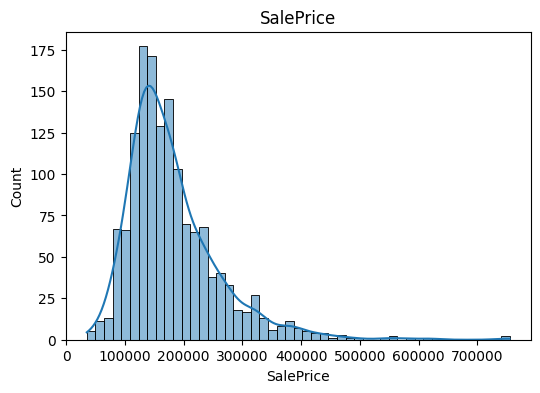

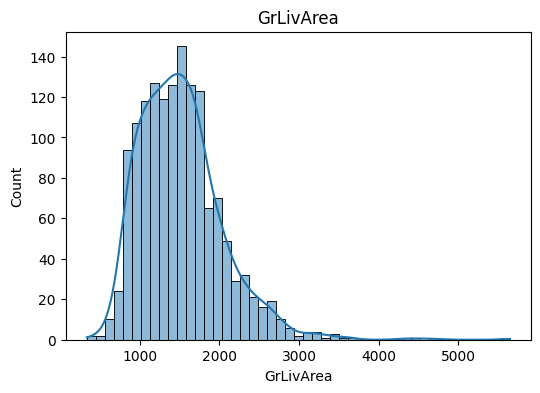

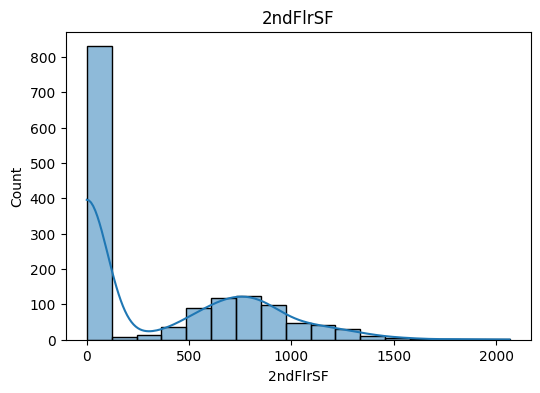

In [11]:
for col in variables:

    plt.figure(figsize=(6,4))

    sns.histplot(datos[col], kde=True)

    plt.title(col)

    plt.show()

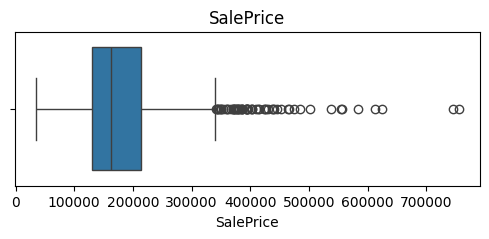

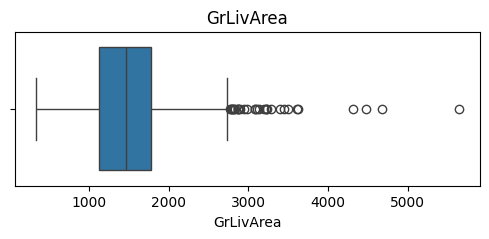

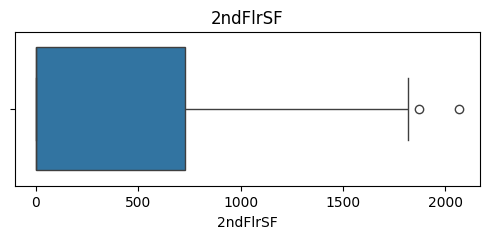

In [12]:
for col in variables:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=datos[col])

    plt.title(col)

    plt.show()

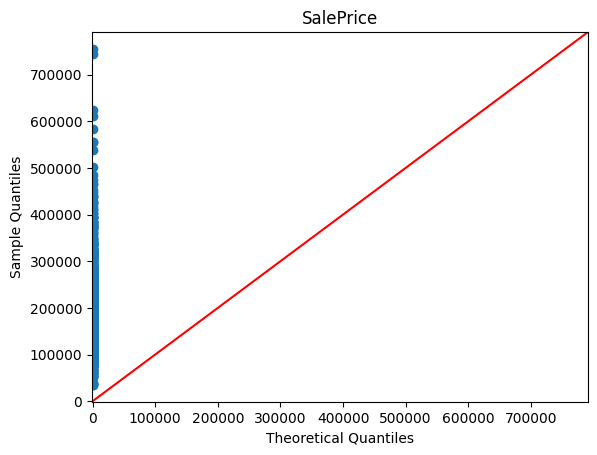

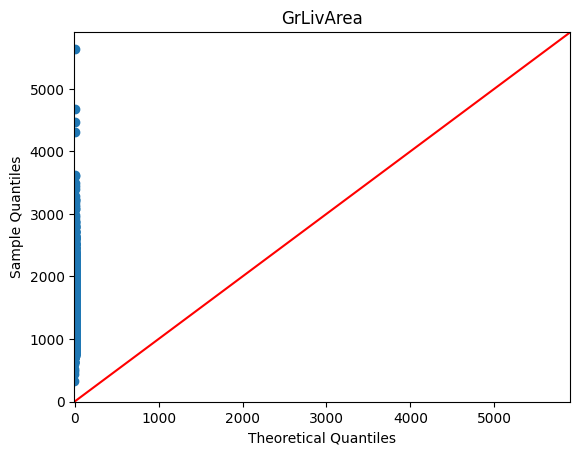

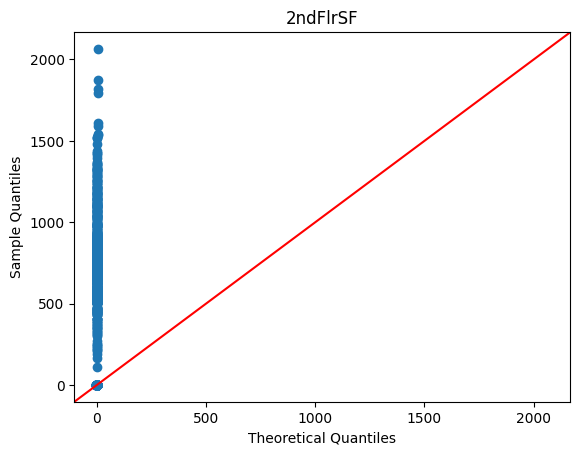

In [13]:
for col in variables:

    sm.qqplot(datos[col], line='45')

    plt.title(col)

    plt.show()

In [14]:
numericas = df.select_dtypes(include=np.number)

correlacion = numericas.corr()

print(correlacion['SalePrice'].sort_values(ascending=False))

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

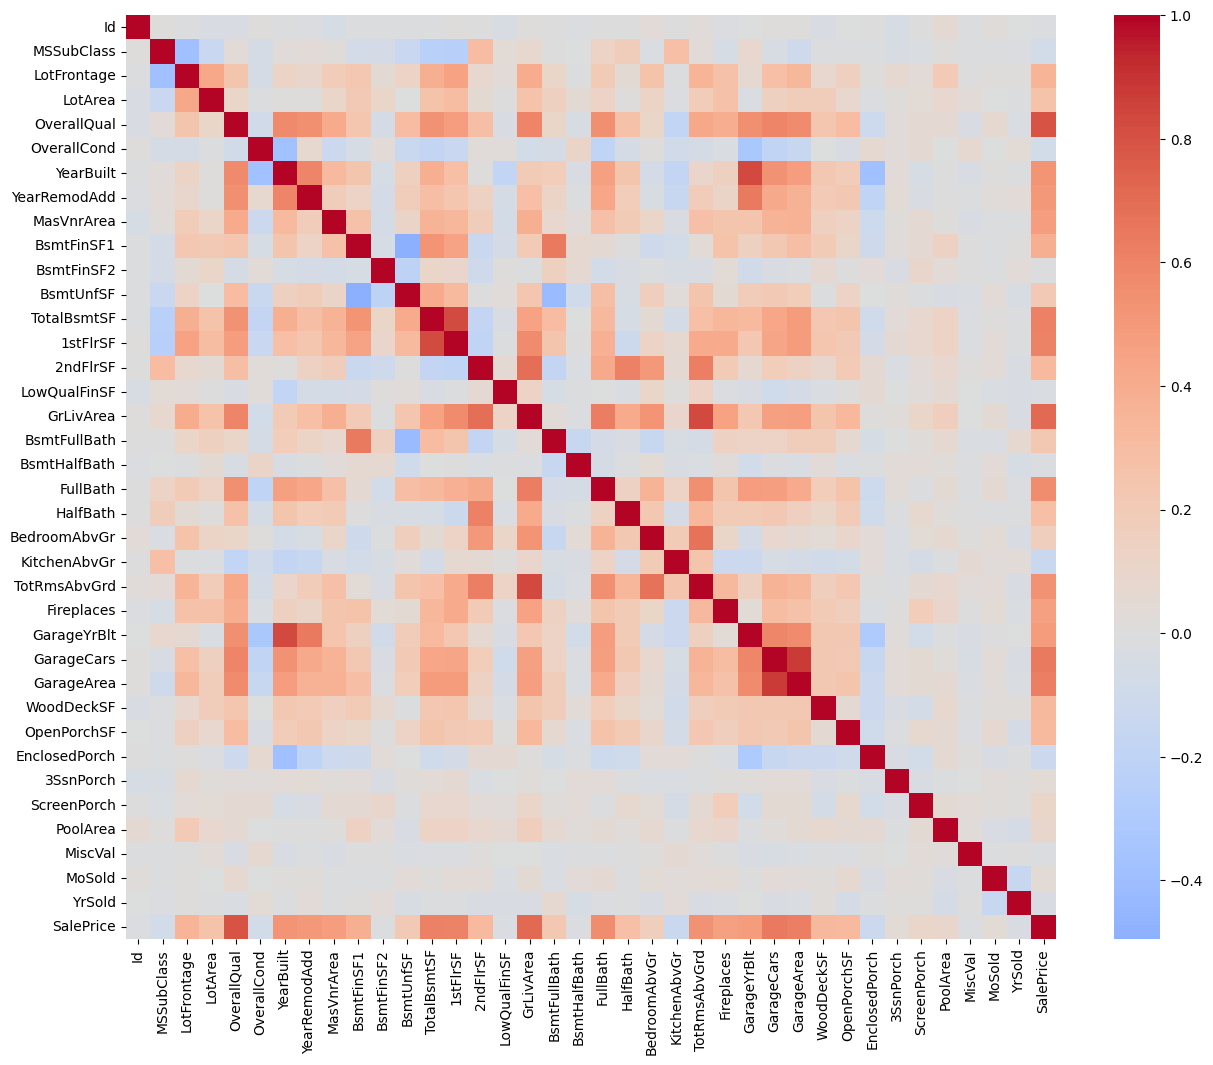

In [15]:
plt.figure(figsize=(15,12))

sns.heatmap(
    correlacion,
    cmap='coolwarm',
    center=0
)

plt.show()

In [16]:
print(correlacion['SalePrice'].sort_values(ascending=False).head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [19]:
numericas = df.select_dtypes(include=np.number)

numericas = numericas.fillna(numericas.mean())

Y = numericas['SalePrice']

X = numericas.drop(columns=['SalePrice'])

X = sm.add_constant(X)

modelo = sm.OLS(Y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     177.1
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:56:35   Log-Likelihood:                -17319.
No. Observations:                1460   AIC:                         3.471e+04
Df Residuals:                    1424   BIC:                         3.490e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.593e+05   1.41e+06      0.325

In [20]:
print(modelo.pvalues.sort_values())

OverallQual      8.031011e-45
MSSubClass       8.353750e-11
BedroomAbvGr     4.006448e-09
GrLivArea        8.459936e-08
MasVnrArea       1.744017e-07
OverallCond      6.391351e-06
LotArea          2.954864e-05
TotRmsAbvGrd     4.269984e-05
YearBuilt        6.226638e-05
BsmtFinSF1       8.204466e-05
GarageCars       9.440776e-05
BsmtFullBath     3.458191e-04
ScreenPorch      1.163017e-03
2ndFlrSF         1.525106e-03
WoodDeckSF       2.969513e-03
1stFlrSF         3.254024e-03
TotalBsmtSF      6.628891e-03
KitchenAbvGr     1.826380e-02
Fireplaces       2.652434e-02
YearRemodAdd     4.949406e-02
GarageYrBlt      7.955389e-02
FullBath         2.228393e-01
PoolArea         2.352791e-01
YrSold           2.694686e-01
LotFrontage      2.747310e-01
HalfBath         4.823169e-01
EnclosedPorch    4.848186e-01
3SsnPorch        5.300210e-01
Id               6.222141e-01
BsmtHalfBath     6.242398e-01
GarageArea       6.730513e-01
MiscVal          6.915309e-01
LowQualFinSF     7.019914e-01
const     

In [21]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif.sort_values(by="VIF", ascending=False))

         Variable           VIF
15       2ndFlrSF           inf
10     BsmtFinSF1           inf
17      GrLivArea           inf
16   LowQualFinSF           inf
14       1stFlrSF           inf
13    TotalBsmtSF           inf
12      BsmtUnfSF           inf
11     BsmtFinSF2           inf
0           const  2.416585e+06
27     GarageCars  5.578949e+00
28     GarageArea  5.468729e+00
7       YearBuilt  5.029641e+00
24   TotRmsAbvGrd  4.889626e+00
26    GarageYrBlt  3.370938e+00
5     OverallQual  3.265164e+00
20       FullBath  2.951113e+00
8    YearRemodAdd  2.425296e+00
22   BedroomAbvGr  2.329674e+00
18   BsmtFullBath  2.219624e+00
21       HalfBath  2.168248e+00
2      MSSubClass  1.657110e+00
23   KitchenAbvGr  1.597118e+00
6     OverallCond  1.596343e+00
25     Fireplaces  1.586110e+00
3     LotFrontage  1.571589e+00
9      MasVnrArea  1.399007e+00
31  EnclosedPorch  1.283815e+00
4         LotArea  1.256787e+00
30    OpenPorchSF  1.222479e+00
29     WoodDeckSF  1.220462e+00
19   Bsm

D:\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [22]:
variables_finales = [

    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    'YearBuilt'

]

In [23]:
X_final = numericas[variables_finales]

X_final = sm.add_constant(X_final)

modelo_final = sm.OLS(Y, X_final).fit()

print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     803.8
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:57:21   Log-Likelihood:                -17476.
No. Observations:                1460   AIC:                         3.497e+04
Df Residuals:                    1453   BIC:                         3.500e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -6.749e+05   8.48e+04     -7.958      

In [24]:
predicciones = modelo_final.predict(X_final)

In [25]:
mse = mean_squared_error(Y, predicciones)

print("MSE:", mse)

MSE: 1460173099.4874954


In [26]:
r2 = r2_score(Y, predicciones)

print("R²:", r2)

R²: 0.7684759716094678
